In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q dpkt

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.0/195.0 kB 8.6 MB/s eta 0:00:00


In [ ]:
import dpkt, glob, os, re
import pandas as pd

PCAP_DIR = '/content/drive/MyDrive/CICIoT2023' # pcap 넣은 폴더 경로로 바꿔줘

files = sorted(glob.glob(PCAP_DIR + '/**/*.pcap', recursive=True))
print(len(files), '개 파일 찾음')

rows = []
for path in files:
    n_pkts, n_bytes = 0, 0
    with open(path, 'rb') as f:
        for ts, buf in dpkt.pcap.Reader(f):
            n_pkts += 1
            n_bytes += len(buf)
    name = os.path.basename(path)
    category = re.sub(r'\d*\.pcap$', '', name)  # 뒤의 숫자 + 확장자 제거
    rows.append({'file': name, 'category': category, 'packets': n_pkts, 'bytes': n_bytes})
    print(name, n_pkts)

df = pd.DataFrame(rows)
df.to_csv(PCAP_DIR + '/pcap_summary.csv', index=False)  # 세션 끊겨도 결과 남게 저장

12 개 파일 찾음
DDoS-ACK_Fragmentation.pcap 2503835
DDoS-HTTP_Flood-.pcap 2881005
DDoS-ICMP_Flood.pcap 26793240
DDoS-ICMP_Fragmentation.pcap 2064692
DDoS-PSHACK_Flood.pcap 26774357
DDoS-RSTFINFlood.pcap 26686473
DDoS-SYN_Flood.pcap 26597011
DDoS-SlowLoris.pcap 2351454
DDoS-SynonymousIP_Flood.pcap 26855630
DDoS-TCP_Flood.pcap 26570958
DDoS-UDP_Flood.pcap 26653551
DDoS-UDP_Fragmentation.pcap 2248843


,files,packets,size_MB,비율(%)
category,,,,
DDoS-SynonymousIP_Flood,1,26855630,1618.31,13.50
DDoS-ICMP_Flood,1,26793240,1619.31,13.47
DDoS-PSHACK_Flood,1,26774357,1619.61,13.46
DDoS-RSTFINFlood,1,26686473,1621.02,13.41
DDoS-UDP_Flood,1,26653551,1621.54,13.40
DDoS-SYN_Flood,1,26597011,1622.45,13.37
DDoS-TCP_Flood,1,26570958,1622.86,13.35
DDoS-HTTP_Flood-,1,2881005,564.76,1.45
DDoS-ACK_Fragmentation,1,2503835,2007.94,1.26


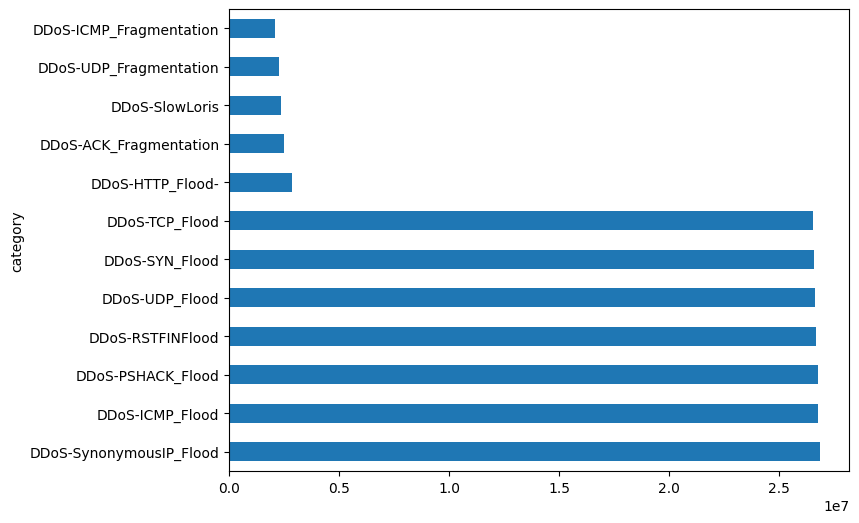

In [ ]:
summary = df.groupby('category').agg(
    files=('file', 'count'),
    packets=('packets', 'sum'),
    size_MB=('bytes', lambda x: x.sum() / 1e6),
)
summary['비율(%)'] = summary['packets'] / summary['packets'].sum() * 100
summary = summary.sort_values('packets', ascending=False).round(2)
summary['packets'].plot(kind='barh', figsize=(8, 6))
summary

In [ ]:
import dpkt, glob, os
import pandas as pd
from collections import Counter

PCAP_DIR = '/content/drive/MyDrive/CICIoT2023'
OUT = PCAP_DIR + '/mac_counts.csv'

done = pd.read_csv(OUT) if os.path.exists(OUT) else pd.DataFrame(columns=['file', 'mac', 'packets'])
finished = set(done['file'])
rows = done.to_dict('records')

files = sorted(glob.glob(PCAP_DIR + '/**/*.pcap', recursive=True))
for path in files:
    name = os.path.basename(path)
    if name in finished:
        print('건너뜀:', name)
        continue
    c = Counter()
    with open(path, 'rb') as f:
        for ts, buf in dpkt.pcap.Reader(f):
            c[buf[0:6]] += 1    # 도착지 MAC
            c[buf[6:12]] += 1   # 출발지 MAC
    for mac, n in c.items():
        rows.append({'file': name, 'mac': mac.hex(':'), 'packets': n})
    pd.DataFrame(rows).to_csv(OUT, index=False)
    print(name, '완료, MAC', len(c), '개')

DDoS-ACK_Fragmentation.pcap 완료, MAC 109 개
DDoS-HTTP_Flood-.pcap 완료, MAC 120 개
DDoS-ICMP_Flood.pcap 완료, MAC 96 개
DDoS-ICMP_Fragmentation.pcap 완료, MAC 108 개
DDoS-PSHACK_Flood.pcap 완료, MAC 102 개
DDoS-RSTFINFlood.pcap 완료, MAC 103 개
DDoS-SYN_Flood.pcap 완료, MAC 103 개
DDoS-SlowLoris.pcap 완료, MAC 98 개
DDoS-SynonymousIP_Flood.pcap 완료, MAC 89 개
DDoS-TCP_Flood.pcap 완료, MAC 106 개
DDoS-UDP_Flood.pcap 완료, MAC 99 개
DDoS-UDP_Fragmentation.pcap 완료, MAC 112 개


In [ ]:
import re
import pandas as pd

DEVICES = """
1C:FE:2B:98:16:DD,Audio,Echo Dot 1
A0:D0:DC:C4:08:FF,Audio,Echo Dot 2
1C:12:B0:9B:0C:EC,Audio,Echo Spot
08:7C:39:CE:6E:2A,Audio,Echo Studio
2C:71:FF:05:F1:15,Audio,Echo Show
CC:F4:11:9C:D0:00,Audio,Google Nest Mini
B0:F1:EC:D3:E7:98,Audio,Harman Kardon
48:A6:B8:F9:1B:88,Audio,Sonos One
9C:8E:CD:1D:AB:9F,Camera,Amcrest
3C:37:86:6F:B9:51,Camera,Arlo Base Station
40:5D:82:35:14:C8,Camera,Arlo Q Indoor
C0:E7:BF:0A:79:D1,Camera,Borun/Sichuan-AI
B0:C5:54:59:2E:99,Camera,D-Link Mini
44:01:BB:EC:10:4A,Camera,HeimVision WiFi
34:75:63:73:F3:36,Camera,Home Eye
7C:A7:B0:CD:18:32,Camera,Luohe Cam Dog
44:BB:3B:00:39:07,Camera,Nest Indoor
70:EE:50:68:0E:32,Camera,Netatmo Camera
10:5A:17:97:A5:C6,Camera,Rbcior
10:2C:6B:1B:43:BE,Camera,SIMCAM 1S
6C:5A:B0:44:1D:90,Camera,TP-Link Tapo
7C:78:B2:86:0D:81,Camera,Wyze
84:7A:B6:64:62:58,Camera,Yi Indoor
84:7A:B6:62:3A:6C,Camera,Yi Indoor 2
2C:D2:6B:66:D2:87,Camera,Yi Outdoor
D4:A6:51:76:06:64,Power Outlet,Teckin Plug 1
D4:A6:51:78:97:4E,Power Outlet,Teckin Plug 2
30:23:03:F3:84:2B,Power Outlet,Wemo Plug 1
30:23:03:F3:57:CB,Power Outlet,Wemo Plug 2
D4:A6:51:20:91:D1,Power Outlet,Yutron Plug 1
D4:A6:51:21:6C:29,Power Outlet,Yutron Plug 2
B8:5F:98:D0:76:E6,Power Outlet,Amazon Plug
50:02:91:1A:CE:E1,Power Outlet,Gosund Power Strip 1
B8:F0:09:03:9A:AF,Power Outlet,Gosund Power Strip 2
B8:F0:09:03:29:79,Power Outlet,Gosund WP2 1
50:02:91:10:AC:D8,Power Outlet,Gosund WP2 2
50:02:91:10:09:8F,Power Outlet,Gosund WP2 3
C4:DD:57:0C:39:94,Power Outlet,Gosund WP3 1
24:A1:60:14:7F:F9,Power Outlet,Gosund WP3 2
84:E3:42:42:ED:0B,기타,Lumiman Bulb
00:17:88:60:D6:4F,기타,Philips Hue Bridge
00:02:75:F6:E3:CB,기타,Smart Board
18:69:D8:EB:D4:3E,기타,Teckin Light Strip
AC:F1:08:4E:00:82,기타,LG Smart TV
70:EE:50:6B:A8:1A,기타,Netatmo Weather Station
8C:85:80:6C:B6:47,기타,Eufy HomeBase 2
68:57:2D:56:AC:47,기타,Atomi Coffee Maker
08:3A:F2:1F:BC:68,기타,Cocoon HVAC Fan
50:02:91:B1:68:0C,기타,Globe Lamp
C4:DD:57:13:07:C6,기타,Gosund Bulb
D4:AD:FC:29:C8:A2,기타,Govee Humidifier
D4:A6:51:30:64:B7,기타,HeimVision Lamp
50:14:79:37:80:18,기타,iRobot Roomba
F4:CF:A2:34:48:6B,기타,LampUX RGB
1C:9D:C2:8C:9A:94,기타,Levoit Air Purifier
D0:73:D5:35:FB:C8,기타,LIFX Bulb
28:6D:97:7A:2B:2D,기타,SmartThings Hub
28:6D:97:9E:F4:D5,기타,AeoTec Hub
B0:09:DA:3E:82:6C,기타,Ring Base Station
AC:17:02:05:34:27,기타,Fibaro Home Center Lite
DC:A6:32:C9:E6:F4,공격자,Raspberry Pi
DC:A6:32:C9:E4:C6,공격자,Raspberry Pi
DC:A6:32:C9:E5:02,공격자,Raspberry Pi
E4:5F:01:55:90:C4,공격자,Raspberry Pi
DC:A6:32:C9:E4:D5,공격자,Raspberry Pi
DC:A6:32:DC:27:D5,공격자,Raspberry Pi
DC:A6:32:C9:E5:EF,공격자,Raspberry Pi
DC:A6:32:C9:E4:AB,공격자,Raspberry Pi
DC:A6:32:C9:E4:90,공격자,Raspberry Pi
DC:A6:32:C9:E5:A4,공격자,Raspberry Pi
"""
dev = {}
for line in DEVICES.strip().splitlines():
    mac, cat, name = line.split(',')
    dev[mac.lower()] = (cat, name)

m = pd.read_csv('/content/drive/MyDrive/CICIoT2023/mac_counts.csv')
m['attack'] = m['file'].str.replace(r'\d*\.pcap$', '', regex=True).str.rstrip('-')
m['device_cat'] = m['mac'].map(lambda x: dev.get(x, ('미확인', x))[0])
m['device'] = m['mac'].map(lambda x: dev.get(x, ('미확인', x))[1])

# 공격자(라즈베리파이)·미확인 MAC 제외하고 IoT 기기만
iot = m[m['device_cat'].isin(['Camera', 'Power Outlet', 'Audio', '기타'])]

table = iot.groupby(['attack', 'device_cat'])['mac'].nunique().unstack(fill_value=0)
for c in ['Camera', 'Power Outlet', 'Audio', '기타']:
    if c not in table:
        table[c] = 0
table['Sensor'] = 0  # Zigbee/Z-Wave라 MAC이 없어서 pcap에서 못 봄
table['확인된 고유 IoT 기기'] = table[['Camera', 'Power Outlet', 'Audio', 'Sensor', '기타']].sum(axis=1)
table = table[['확인된 고유 IoT 기기', 'Camera', 'Power Outlet', 'Audio', 'Sensor', '기타']]
table

device_cat,확인된 고유 IoT 기기,Camera,Power Outlet,Audio,Sensor,기타
attack,,,,,,
DDoS-ACK_Fragmentation,54,17,12,6,0,19
DDoS-HTTP_Flood,58,16,14,8,0,20
DDoS-ICMP_Flood,56,17,13,8,0,18
DDoS-ICMP_Fragmentation,59,16,14,8,0,21
DDoS-PSHACK_Flood,56,17,12,8,0,19
DDoS-RSTFINFlood,53,16,12,7,0,18
DDoS-SYN_Flood,60,17,14,8,0,21
DDoS-SlowLoris,52,15,12,8,0,17
DDoS-SynonymousIP_Flood,51,15,12,7,0,17


In [ ]:
import re
import pandas as pd
from IPython.display import display

DEVICES = """
1C:FE:2B:98:16:DD,Audio,Echo Dot 1
A0:D0:DC:C4:08:FF,Audio,Echo Dot 2
1C:12:B0:9B:0C:EC,Audio,Echo Spot
08:7C:39:CE:6E:2A,Audio,Echo Studio
2C:71:FF:05:F1:15,Audio,Echo Show
CC:F4:11:9C:D0:00,Audio,Google Nest Mini
B0:F1:EC:D3:E7:98,Audio,Harman Kardon
48:A6:B8:F9:1B:88,Audio,Sonos One
9C:8E:CD:1D:AB:9F,Camera,Amcrest
3C:37:86:6F:B9:51,Camera,Arlo Base Station
40:5D:82:35:14:C8,Camera,Arlo Q Indoor
C0:E7:BF:0A:79:D1,Camera,Borun/Sichuan-AI
B0:C5:54:59:2E:99,Camera,D-Link Mini
44:01:BB:EC:10:4A,Camera,HeimVision WiFi
34:75:63:73:F3:36,Camera,Home Eye
7C:A7:B0:CD:18:32,Camera,Luohe Cam Dog
44:BB:3B:00:39:07,Camera,Nest Indoor
70:EE:50:68:0E:32,Camera,Netatmo Camera
10:5A:17:97:A5:C6,Camera,Rbcior
10:2C:6B:1B:43:BE,Camera,SIMCAM 1S
6C:5A:B0:44:1D:90,Camera,TP-Link Tapo
7C:78:B2:86:0D:81,Camera,Wyze
84:7A:B6:64:62:58,Camera,Yi Indoor
84:7A:B6:62:3A:6C,Camera,Yi Indoor 2
2C:D2:6B:66:D2:87,Camera,Yi Outdoor
D4:A6:51:76:06:64,Power Outlet,Teckin Plug 1
D4:A6:51:78:97:4E,Power Outlet,Teckin Plug 2
30:23:03:F3:84:2B,Power Outlet,Wemo Plug 1
30:23:03:F3:57:CB,Power Outlet,Wemo Plug 2
D4:A6:51:20:91:D1,Power Outlet,Yutron Plug 1
D4:A6:51:21:6C:29,Power Outlet,Yutron Plug 2
B8:5F:98:D0:76:E6,Power Outlet,Amazon Plug
50:02:91:1A:CE:E1,Power Outlet,Gosund Power Strip 1
B8:F0:09:03:9A:AF,Power Outlet,Gosund Power Strip 2
B8:F0:09:03:29:79,Power Outlet,Gosund WP2 1
50:02:91:10:AC:D8,Power Outlet,Gosund WP2 2
50:02:91:10:09:8F,Power Outlet,Gosund WP2 3
C4:DD:57:0C:39:94,Power Outlet,Gosund WP3 1
24:A1:60:14:7F:F9,Power Outlet,Gosund WP3 2
84:E3:42:42:ED:0B,Lighting,Lumiman Bulb
18:69:D8:EB:D4:3E,Lighting,Teckin Light Strip
50:02:91:B1:68:0C,Lighting,Globe Lamp
C4:DD:57:13:07:C6,Lighting,Gosund Bulb
D4:A6:51:30:64:B7,Lighting,HeimVision Lamp
F4:CF:A2:34:48:6B,Lighting,LampUX RGB
D0:73:D5:35:FB:C8,Lighting,LIFX Bulb
00:02:75:F6:E3:CB,Home Automation,Smart Board
AC:F1:08:4E:00:82,Home Automation,LG Smart TV
70:EE:50:6B:A8:1A,Home Automation,Netatmo Weather Station
68:57:2D:56:AC:47,Home Automation,Atomi Coffee Maker
08:3A:F2:1F:BC:68,Home Automation,Cocoon HVAC Fan
D4:AD:FC:29:C8:A2,Home Automation,Govee Humidifier
50:14:79:37:80:18,Home Automation,iRobot Roomba
1C:9D:C2:8C:9A:94,Home Automation,Levoit Air Purifier
00:17:88:60:D6:4F,Hub,Philips Hue Bridge
8C:85:80:6C:B6:47,Hub,Eufy HomeBase 2
28:6D:97:7A:2B:2D,Hub,SmartThings Hub
28:6D:97:9E:F4:D5,Hub,AeoTec Hub
B0:09:DA:3E:82:6C,Hub,Ring Base Station
AC:17:02:05:34:27,Hub,Fibaro Home Center Lite
DC:A6:32:C9:E6:F4,NextGen,Raspberry Pi
DC:A6:32:C9:E4:C6,NextGen,Raspberry Pi
DC:A6:32:C9:E5:02,NextGen,Raspberry Pi
E4:5F:01:55:90:C4,NextGen,Raspberry Pi
DC:A6:32:C9:E4:D5,NextGen,Raspberry Pi
DC:A6:32:DC:27:D5,NextGen,Raspberry Pi
DC:A6:32:C9:E5:EF,NextGen,Raspberry Pi
DC:A6:32:C9:E4:AB,NextGen,Raspberry Pi
DC:A6:32:C9:E4:90,NextGen,Raspberry Pi
DC:A6:32:C9:E5:A4,NextGen,Raspberry Pi
"""
dev = {}
for line in DEVICES.strip().splitlines():
    mac, cat, name = line.split(',')
    dev[mac.lower()] = (cat, name)

m = pd.read_csv('/content/drive/MyDrive/CICIoT2023/mac_counts.csv')
m['attack'] = m['file'].str.replace(r'\d*\.pcap$', '', regex=True).str.rstrip('-')
m['device_cat'] = m['mac'].map(lambda x: dev.get(x, ('미확인', x))[0])
m['device'] = m['mac'].map(lambda x: dev.get(x, ('미확인', x))[1])

CATS = ['Power Outlet', 'Camera', 'Sensor', 'Home Automation', 'Lighting', 'NextGen', 'Audio', 'Hub']
known = m[m['device_cat'].isin(CATS)]
iot = known[known['device_cat'] != 'NextGen']   # 공격자(라즈베리파이) 뺀 공격 대상 기기

# 공격별 표 (기기 종류별 고유 기기 수)
table = known.groupby(['attack', 'device_cat'])['mac'].nunique().unstack(fill_value=0)
table = table.reindex(columns=CATS, fill_value=0)   # 안 잡힌 종류도 0으로 칸 유지
table['합계(공격자 제외)'] = table.drop(columns='NextGen').sum(axis=1)
table['합계'] = table[CATS].sum(axis=1)

# 12개 공격 전체 기준 (같은 기기는 한 번만 셈)
overall = known.groupby('device_cat')['mac'].nunique().reindex(CATS, fill_value=0)
overall['합계(공격자 제외)'] = overall.drop('NextGen').sum()
overall['합계'] = overall[CATS].sum()
table.loc['전체(중복 제외)'] = overall

display(table)
display(overall.to_frame('고유 기기 수'))

device_cat,Power Outlet,Camera,Sensor,Home Automation,Lighting,NextGen,Audio,Hub,합계(공격자 제외),합계
attack,,,,,,,,,,
DDoS-ACK_Fragmentation,12,17,0,8,6,10,6,5,54,64
DDoS-HTTP_Flood,14,16,0,8,6,10,8,6,58,68
DDoS-ICMP_Flood,13,17,0,8,5,10,8,5,56,66
DDoS-ICMP_Fragmentation,14,16,0,8,7,10,8,6,59,69
DDoS-PSHACK_Flood,12,17,0,7,7,10,8,5,56,66
DDoS-RSTFINFlood,12,16,0,7,6,10,7,5,53,63
DDoS-SYN_Flood,14,17,0,8,7,10,8,6,60,70
DDoS-SlowLoris,12,15,0,6,6,10,8,5,52,62
DDoS-SynonymousIP_Flood,12,15,0,6,6,10,7,5,51,61


,고유 기기 수
device_cat,
Power Outlet,14
Camera,17
Sensor,0
Home Automation,8
Lighting,7
NextGen,10
Audio,8
Hub,6
합계(공격자 제외),60


In [ ]:
g = iot[iot['device_cat'] != '기타'].groupby('device_cat').agg(
    기기수=('mac', 'nunique'),
    패킷수=('packets', 'sum'),
)
g['기기당 패킷'] = (g['패킷수'] / g['기기수']).round(0)
g.sort_values('패킷수', ascending=False)

,기기수,패킷수,기기당 패킷
device_cat,,,
Audio,8,159589063,19948633.0
Camera,17,21598425,1270496.0
Hub,6,16054356,2675726.0
Lighting,7,200281,28612.0
Power Outlet,14,170877,12206.0
Home Automation,8,141035,17629.0


In [ ]:
# 1) Audio 안에서 특정 기기 하나에 몰렸는지 (기기 TOP 10)
iot.groupby(['device_cat', 'device'])['packets'].sum().sort_values(ascending=False).head(10)

device_cat  device          
Audio       Echo Dot 1          79252026
            Echo Spot           48568405
Camera      Amcrest             18433398
Audio       Echo Show           15460385
Hub         AeoTec Hub          12821156
Audio       Echo Dot 2           8309379
            Google Nest Mini     7431206
Hub         Eufy HomeBase 2      2685593
Camera      D-Link Mini          1590427
Audio       Harman Kardon         480931
Name: packets, dtype: int64

In [ ]:
# 2) 12개 공격 모두에서 Audio가 1등인지 (공격별 종류별 패킷 수)
iot.pivot_table(index='attack', columns='device_cat', values='packets', aggfunc='sum')

device_cat,Audio,Camera,Home Automation,Hub,Lighting,Power Outlet
attack,,,,,,
DDoS-ACK_Fragmentation,71709,1503824,11288,820921,101639,9044
DDoS-HTTP_Flood,433447,1342922,13396,213290,9728,24628
DDoS-ICMP_Flood,26715923,24543,5335,27882,3204,11270
DDoS-ICMP_Fragmentation,1967393,35590,9043,19074,7821,13190
DDoS-PSHACK_Flood,24756726,1983082,4621,6046,5777,9577
DDoS-RSTFINFlood,14624535,34743,9674,11995578,5015,10678
DDoS-SYN_Flood,23569287,2934332,8881,50328,9550,16170
DDoS-SlowLoris,341618,1390850,46386,177043,34183,31661
DDoS-SynonymousIP_Flood,12924389,12050313,2190,1859323,3625,5944
